In [5]:
import sys
import os
import mne
import matplotlib.pyplot as plt
from src.eeg_processor import EEGProcessor

In [6]:
# Get the first subject for processing
ROOT_DIR = os.getcwd()
data_folder = os.path.join(ROOT_DIR, "..", "data")
file_path = "derivatives/sub-001/eeg/sub-001_task-eyesclosed_eeg.set"

processor = EEGProcessor(data_folder, file_path)

In [7]:
# Load data
raw_data = processor.load_data()

# Epoch data
epochs_data = processor.epoch_data()

# Compute PSD
psds, freqs, ch_names = processor.compute_psd()

# Compute alpha-band power
band_psd = processor.compute_band_psd(
    band="alpha"
)

# Map the alpha power to 5x5 grid
mapped_data = processor.map_channel_locations()

# Interpolate each grid to 32x32
interpolated_data = processor.interpolate()


Not setting metadata
599 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 599 events and 500 original time points ...
0 bad epochs dropped
Effective window size : 1.000 (s)


The initial 5×5 grid reflects the spatial arrangement of the 19 electrodes and the interpolated 32×32 grid smooths the representation and increases its resolution.

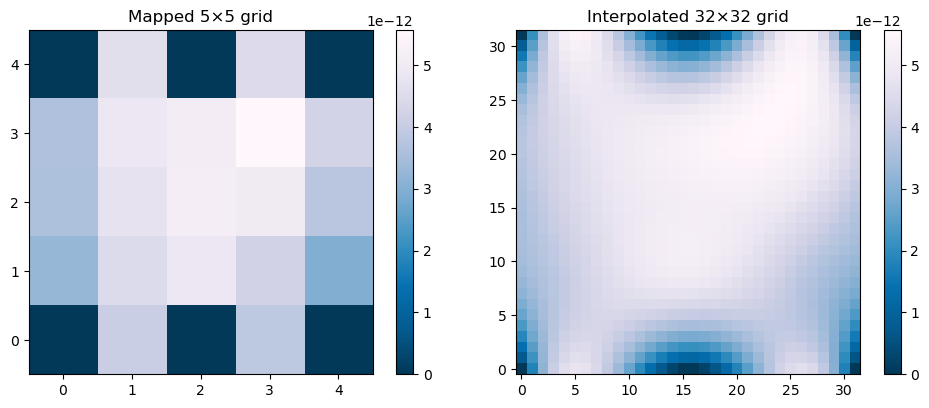

In [11]:
# Choose an example epoch
epoch_ind = 5

os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(10, 4))

# Plot grid before and after interpolation
plt.subplot(1, 2, 1)
plt.imshow(mapped_data[epoch_ind], cmap='PuBu_r', origin="lower")
plt.title("Mapped 5×5 grid")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(interpolated_data[epoch_ind], cmap="PuBu_r", origin="lower")
plt.title("Interpolated 32×32 grid") 
plt.colorbar()

plt.tight_layout()
plt.savefig("figures/mapped and interpolated grids.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Save each image separately for further visualisation
epoch_ind = 5

fig = plt.figure(figsize=(5, 5))
plt.imshow(mapped_data[epoch_ind], cmap='PuBu_r', origin="lower")
plt.axis("off")
fig.savefig("figures/mapped_grid.png", dpi=300, bbox_inches="tight", pad_inches=0)  # Remove white border
plt.close(fig)

fig = plt.figure(figsize=(5, 5))
plt.imshow(interpolated_data[epoch_ind], cmap="PuBu_r", origin="lower")
plt.axis("off")
fig.savefig("figures/interpolated_grid.png", dpi=300, bbox_inches="tight", pad_inches=0)
plt.close(fig)

The six images show the temporal variation across six consecutive epochs from the same subject in the alpha band.

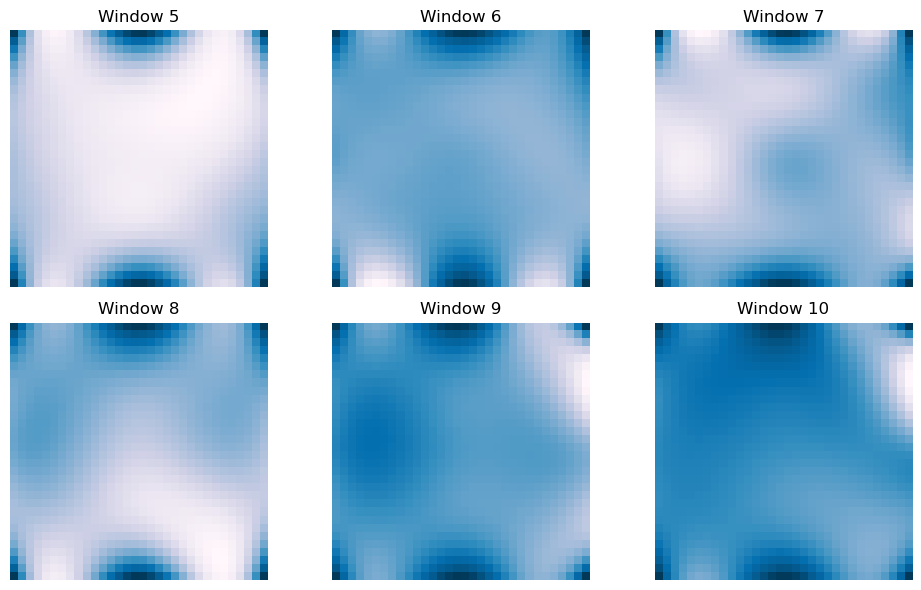

In [17]:
# Alpha band interpolated grids through multiple epochs
n = 6
plt.figure(figsize=(10, 6))
for i in range(n):
    plt.subplot(2, 3, i+1)
    plt.imshow(interpolated_data[i+5], cmap="PuBu_r", origin="lower")
    plt.title(f"Window {i+5}")
    # plt.colorbar()
    plt.axis("off")
plt.savefig("figures/multiple_interpolated_grids.pdf", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [16]:
# Save each image separately for further visualisation
os.makedirs("figures/multiple_interpolated_grids", exist_ok=True)

for i in range(n):
    fig = plt.figure(figsize=(5, 5))
    plt.imshow(interpolated_data[i+5], cmap="PuBu_r", origin="lower")
    plt.axis("off")
    fig.savefig(f"figures/multiple_interpolated_grids/window_{i}_interpolated_grid.png", dpi=300, bbox_inches="tight", pad_inches=0)
    plt.close(fig)

The topographic variation across frequency bands for the same epoch, showing how spatial PSD patterns differ between the bands.

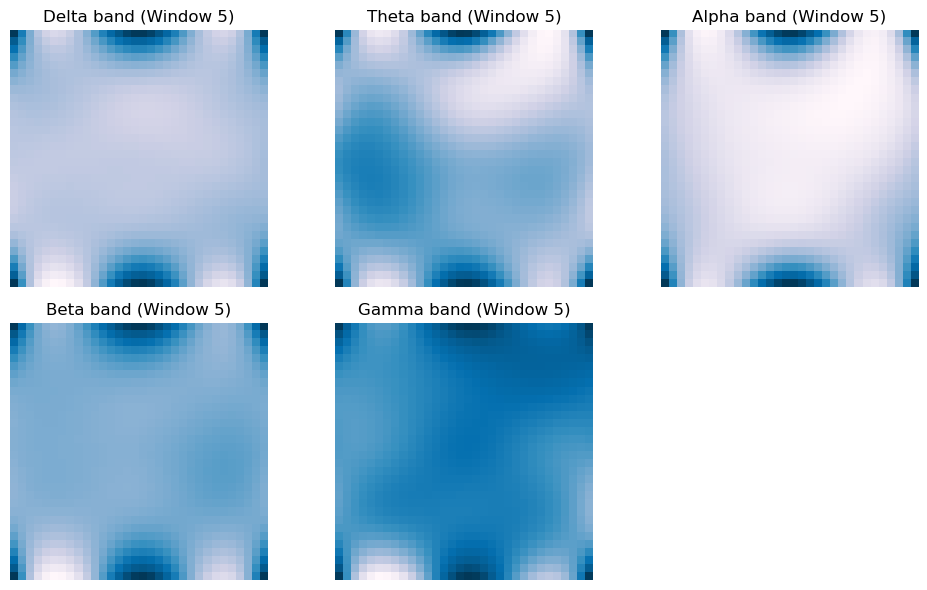

In [12]:
# Grids from different frequency bands for a chosen epoch
epoch_ind = 5

plt.figure(figsize=(10, 6))
for i, band in enumerate(["delta", "theta", "alpha", "beta", "gamma"]):
    band_psd = processor.compute_band_psd(band=band)
    mapped = processor.map_channel_locations()
    interpolated = processor.interpolate()
    plt.subplot(2, 3, i+1)
    plt.imshow(interpolated[epoch_ind], cmap="PuBu_r", origin="lower")
    plt.title(f"{band.capitalize()} band (Window {epoch_ind})")
    # plt.colorbar()
    plt.axis("off")
plt.tight_layout()
plt.savefig("figures/different_frequency_bands.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [395]:
# Save each image separately for further visualisation
os.makedirs("figures/multiple_band_grid", exist_ok=True)

epoch_ind = 5

for i, band in enumerate(["delta", "theta", "alpha", "beta", "gamma"]):
    fig = plt.figure(figsize=(5, 5))
    band_psd = processor.compute_band_psd(band=band)
    mapped = processor.map_channel_locations()
    interpolated = processor.interpolate()
    plt.imshow(interpolated[epoch_ind], cmap="PuBu_r", origin="lower")
    # plt.colorbar()
    plt.axis("off")
    fig.savefig(f"figures/multiple_band_grid/{band}_band_grid.png", dpi=300, bbox_inches="tight", pad_inches=0)
    plt.close(fig)